In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings

In [2]:
# --- Configuration ---

# !!! IMPORTANT: USER MUST SET THIS PATH !!!
# Set the path to the directory containing your CSV data files
# Example for Windows: data_directory = r"C:\sem4_real\IBC\Experiment\word_superiority_copy\data"
# Example for Mac/Linux: data_directory = "/path/to/your/experiment/data"
data_directory = "./"

# Define the columns you want to keep from the CSV files
# Based on the user's list
columns_to_keep = [
    'participant',
    'what is your first language?', 
    # Note: Column name might vary slightly 
    # if spaces/question marks are handled differently
    'date',
    'expName',
    'psychopyVersion',
    'OS',
    'frameRate',
    'trial.started',
    'trial.stopped',
    'key_resp.keys',
    'key_resp.corr', # Primary accuracy column
    'key_resp.rt',   # Primary reaction time column
    #'correct',       # Often redundant with key_resp.corr, preferring key_resp.corr
    #'rt',            # Often redundant with key_resp.rt, preferring key_resp.rt
    'trials.ran',
    'this_word',     # Might be called 'word' or 'stimulus'
    'critical_letter',
    'letter_position',
    'this_question', # Might vary
    'corr_ans',      # Correct answer key/label
    'condition'      # Essential for analysis ('word' / 'nonword')
]

# Essential columns absolutely required for the core analysis
essential_analysis_columns = ['participant', 'condition', 'key_resp.corr', 'key_resp.rt']


In [3]:
# --- Function Definitions ---

def load_and_combine_data(directory, columns_to_select, essential_cols):
    """
    Loads all CSV files from a directory, selects specified columns,
    and combines them into a single pandas DataFrame. Handles errors gracefully.

    Args:
        directory (str): Path to the directory containing CSV files.
        columns_to_select (list): List of column names to try and keep.
        essential_cols (list): List of column names absolutely required for analysis.

    Returns:
        pandas.DataFrame or None: Combined DataFrame or None if no valid data found.
    """
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    if not all_files:
        print(f"Error: No CSV files found in the directory: {directory}")
        return None

    df_list = []
    print(f"Found {len(all_files)} CSV files. Attempting to load...")

    for filename in all_files:
        try:
            # Try reading with default comma delimiter
            try:
                df_single = pd.read_csv(filename, low_memory=False)
            except pd.errors.ParserError:
                 # If comma fails, try semicolon (sometimes happens with regional settings)
                 print(f"Warning: Comma delimiter failed for {os.path.basename(filename)}. Trying semicolon...")
                 df_single = pd.read_csv(filename, low_memory=False, delimiter=';')

            # Check for essential columns before proceeding
            missing_essentials = [col for col in essential_cols if col not in df_single.columns]
            if missing_essentials:
                print(f"Warning: Skipping file {os.path.basename(filename)} - Missing essential columns: {missing_essentials}")
                continue

            # Select only the columns that exist in *both* the file and the desired list
            cols_in_file = df_single.columns.tolist()
            final_cols_to_select = [col for col in columns_to_select if col in cols_in_file]

            # Re-check if essential columns are still present after intersection
            missing_essentials_after_select = [col for col in essential_cols if col not in final_cols_to_select]
            if missing_essentials_after_select:
                 # This case should be rare if the first check passed, but good to have
                 print(f"Warning: Skipping file {os.path.basename(filename)} - Essential columns mismatch after selection: {missing_essentials_after_select}")
                 continue

            df_list.append(df_single[final_cols_to_select])
            # print(f"Successfully loaded and selected columns from: {os.path.basename(filename)}") # Uncomment for verbose loading

        except FileNotFoundError:
            print(f"Error: File not found during processing: {filename}")
        except pd.errors.EmptyDataError:
            print(f"Warning: Skipping empty file: {os.path.basename(filename)}")
        except Exception as e:
            print(f"Warning: Skipping file {os.path.basename(filename)} due to unexpected error: {e}")

    if not df_list:
        print("Error: No valid data could be loaded from any CSV file.")
        return None

    print(f"Successfully loaded data from {len(df_list)} files.")
    # Combine all dataframes
    combined_df = pd.concat(df_list, ignore_index=True)
    print(f"Combined data shape: {combined_df.shape}")
    return combined_df

def clean_data(df, essential_cols):
    """Cleans the combined dataframe."""
    print("\n--- Cleaning Data ---")
    initial_rows = len(df)

    # Convert essential columns to numeric, coercing errors
    for col in ['key_resp.corr', 'key_resp.rt']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            print(f"Error: Essential column '{col}' not found for cleaning.")
            return None # Cannot proceed without essential columns

    # Ensure 'participant' and 'condition' are suitable types
    if 'participant' in df.columns:
         df['participant'] = df['participant'].astype(str) # Treat participant ID as string
    else:
         print("Error: Essential column 'participant' not found.")
         return None

    if 'condition' in df.columns:
        df['condition'] = df['condition'].astype(str).str.lower().str.strip() # Standardize condition names
        # Check if expected conditions are present
        valid_conditions = {'word', 'nonword'}
        found_conditions = set(df['condition'].unique())
        if not valid_conditions.issubset(found_conditions):
            print(f"Warning: Expected conditions 'word' and 'nonword'. Found: {found_conditions}. Check 'condition' column content.")
            # Filter out unexpected conditions if necessary, or handle as needed
            df = df[df['condition'].isin(valid_conditions)]
            print(f"Filtered data to include only conditions: {valid_conditions}")
    else:
        print("Error: Essential column 'condition' not found.")
        return None

    # Handle missing values in essential columns
    # Drop rows where participant or condition is missing (shouldn't happen ideally)
    df.dropna(subset=['participant', 'condition'], inplace=True)
    # Drop rows where accuracy is missing (trial likely incomplete/error)
    df.dropna(subset=['key_resp.corr'], inplace=True)
    # Note: We keep rows where key_resp.rt might be NaN if accuracy is 0 (incorrect response)

    rows_after_cleaning = len(df)
    print(f"Removed {initial_rows - rows_after_cleaning} rows during cleaning (missing essential data).")
    print(f"Cleaned data shape: {df.shape}")
    return df

def calculate_summary_stats(df_clean):
    """Calculates summary stats per participant per condition."""
    print("\n--- Calculating Summary Statistics per Participant ---")

    # Calculate Mean Accuracy per participant per condition
    accuracy_summary = df_clean.groupby(['participant', 'condition'])['key_resp.corr'].mean().reset_index()
    accuracy_summary = accuracy_summary.pivot(index='participant', columns='condition', values='key_resp.corr').reset_index()
    accuracy_summary.columns.name = None # Clean up column names if pivoted
    accuracy_summary.rename(columns={'word': 'acc_word', 'nonword': 'acc_nonword'}, inplace=True)

    # Filter for correct trials ONLY for RT calculation
    df_correct = df_clean[df_clean['key_resp.corr'] == 1].copy()

    # Check if any correct trials remain
    if df_correct.empty:
        print("Error: No correct trials found in the dataset. Cannot calculate RT statistics.")
        # Return only accuracy summary if RT cannot be calculated
        return accuracy_summary, None

    # Calculate Median RT per participant per condition (only on correct trials)
    rt_summary = df_correct.groupby(['participant', 'condition'])['key_resp.rt'].median().reset_index()
    rt_summary = rt_summary.pivot(index='participant', columns='condition', values='key_resp.rt').reset_index()
    rt_summary.columns.name = None # Clean up column names if pivoted
    rt_summary.rename(columns={'word': 'rt_median_word', 'nonword': 'rt_median_nonword'}, inplace=True)

    # Merge accuracy and RT summaries
    participant_summary = pd.merge(accuracy_summary, rt_summary, on='participant', how='outer')

    print(f"Summary calculated for {len(participant_summary)} participants.")
    # Display first few rows of summary data
    print("Sample of participant summary data:")
    print(participant_summary.head())

    return participant_summary, participant_summary # Returning twice for consistency below, though only one df

def perform_analysis(summary_df):
    """Performs Wilcoxon tests and generates output."""
    if summary_df is None:
        print("Error: No summary data available for analysis.")
        return None, None

    print("\n--- Performing Wilcoxon Signed Rank Tests ---")

    # --- Accuracy Analysis ---
    acc_results = None
    if 'acc_word' in summary_df.columns and 'acc_nonword' in summary_df.columns:
        # Drop participants with missing data in EITHER condition for the paired test
        acc_data = summary_df[['acc_word', 'acc_nonword']].dropna()
        print(f"Analyzing accuracy for {len(acc_data)} participants (after dropping missing pairs).")
        if len(acc_data) > 0:
            try:
                # Test if 'word' accuracy > 'nonword' accuracy
                stat, p_value = stats.wilcoxon(acc_data['acc_word'], acc_data['acc_nonword'], alternative='greater', zero_method='zsplit')
                acc_results = {'statistic': stat, 'p_value': p_value, 'n_pairs': len(acc_data)}
                print("\nAccuracy (Word vs Nonword):")
                print(f"  Wilcoxon Statistic: {stat:.4f}")
                print(f"  P-value (one-tailed, word > nonword): {p_value:.4f}")
                if p_value < 0.05:
                    print("  Result: Significant difference found (p < 0.05). Word accuracy is higher.")
                else:
                    print("  Result: No significant difference found (p >= 0.05).")
            except ValueError as e:
                print(f"  Could not perform Wilcoxon test for accuracy: {e}")
                acc_results = {'error': str(e)}
        else:
            print("  Not enough paired data to perform accuracy analysis.")
    else:
        print("  Accuracy columns ('acc_word', 'acc_nonword') not found in summary data.")


    # --- Reaction Time Analysis ---
    rt_results = None
    if 'rt_median_word' in summary_df.columns and 'rt_median_nonword' in summary_df.columns:
         # Drop participants with missing data in EITHER condition for the paired test
        rt_data = summary_df[['rt_median_word', 'rt_median_nonword']].dropna()
        print(f"\nAnalyzing Median RT for {len(rt_data)} participants (on correct trials, after dropping missing pairs).")

        if len(rt_data) > 0:
            # Check if all differences are zero (would cause Wilcoxon error)
            diffs = rt_data['rt_median_word'] - rt_data['rt_median_nonword']
            if np.all(diffs == 0):
                 print("  Warning: All paired differences for RT are zero. Wilcoxon test cannot be performed.")
                 rt_results = {'error': 'All differences are zero.'}
            else:
                try:
                    # Test if 'word' RT < 'nonword' RT
                    stat, p_value = stats.wilcoxon(rt_data['rt_median_word'], rt_data['rt_median_nonword'], alternative='less', zero_method='zsplit')
                    rt_results = {'statistic': stat, 'p_value': p_value, 'n_pairs': len(rt_data)}
                    print("\nMedian Reaction Time (Word vs Nonword - Correct Trials):")
                    print(f"  Wilcoxon Statistic: {stat:.4f}")
                    print(f"  P-value (one-tailed, word < nonword): {p_value:.4f}")
                    if p_value < 0.05:
                        print("  Result: Significant difference found (p < 0.05). Word RT is faster.")
                    else:
                        print("  Result: No significant difference found (p >= 0.05).")
                except ValueError as e:
                    print(f"  Could not perform Wilcoxon test for RT: {e}")
                    rt_results = {'error': str(e)}
        else:
            print("  Not enough paired data to perform RT analysis.")
    else:
        print("\nMedian RT columns ('rt_median_word', 'rt_median_nonword') not found in summary data.")

    return acc_results, rt_results

def create_visualizations(summary_df):
    """Generates boxplots for accuracy and RT."""
    if summary_df is None:
        print("\nError: No summary data available for visualization.")
        return

    print("\n--- Generating Visualizations ---")
    plt.style.use('seaborn-v0_8-darkgrid') # Use a visually appealing style

    # --- Accuracy Plot ---
    if 'acc_word' in summary_df.columns and 'acc_nonword' in summary_df.columns:
        acc_melt = pd.melt(summary_df, id_vars=['participant'], value_vars=['acc_word', 'acc_nonword'],
                           var_name='Condition', value_name='Mean Accuracy')
        acc_melt['Condition'] = acc_melt['Condition'].map({'acc_word': 'Word', 'acc_nonword': 'Nonword'}) # Rename for plot

        plt.figure(figsize=(6, 6))
        sns.boxplot(data=acc_melt, x='Condition', y='Mean Accuracy', palette='pastel')
        sns.stripplot(data=acc_melt, x='Condition', y='Mean Accuracy', color=".3", alpha=0.5, jitter=0.1) # Add individual points
        plt.title('Mean Accuracy per Participant by Condition')
        plt.ylabel('Mean Accuracy (Proportion Correct)')
        plt.ylim(0, 1.1) # Set y-axis limits for accuracy
        plt.tight_layout()
        try:
            plt.savefig('accuracy_boxplot.png')
            print("Saved accuracy boxplot as 'accuracy_boxplot.png'")
        except Exception as e:
            print(f"Warning: Could not save accuracy plot: {e}")
        plt.show()

    # --- Reaction Time Plot ---
    if 'rt_median_word' in summary_df.columns and 'rt_median_nonword' in summary_df.columns:
        rt_melt = pd.melt(summary_df, id_vars=['participant'], value_vars=['rt_median_word', 'rt_median_nonword'],
                          var_name='Condition', value_name='Median RT (s)')
        rt_melt['Condition'] = rt_melt['Condition'].map({'rt_median_word': 'Word', 'rt_median_nonword': 'Nonword'}) # Rename for plot

        plt.figure(figsize=(6, 6))
        sns.boxplot(data=rt_melt, x='Condition', y='Median RT (s)', palette='pastel')
        sns.stripplot(data=rt_melt, x='Condition', y='Median RT (s)', color=".3", alpha=0.5, jitter=0.1) # Add individual points
        plt.title('Median Reaction Time per Participant by Condition (Correct Trials)')
        plt.ylabel('Median Reaction Time (seconds)')
        # Consider setting appropriate y-limits based on typical RTs if needed
        # plt.ylim(0, 2.0)
        plt.tight_layout()
        try:
            plt.savefig('rt_boxplot.png')
            print("Saved RT boxplot as 'rt_boxplot.png'")
        except Exception as e:
            print(f"Warning: Could not save RT plot: {e}")
        plt.show()

def display_summary_output(summary_df, acc_results, rt_results):
     """Prints final summary statistics."""
     if summary_df is None:
         print("\nNo summary statistics to display.")
         return

     print("\n--- Overall Summary Statistics (Across Participants) ---")

     if 'acc_word' in summary_df.columns and 'acc_nonword' in summary_df.columns:
         print("\nAccuracy:")
         print(f"  Mean Word Accuracy:   {summary_df['acc_word'].mean():.3f} (SD={summary_df['acc_word'].std():.3f})")
         print(f"  Mean Nonword Accuracy:{summary_df['acc_nonword'].mean():.3f} (SD={summary_df['acc_nonword'].std():.3f})")
         if acc_results and 'error' not in acc_results:
            print(f"  Wilcoxon Test (n={acc_results['n_pairs']}): p = {acc_results['p_value']:.4f}")
         elif acc_results and 'error' in acc_results:
            print(f"  Wilcoxon Test Error: {acc_results['error']}")

     if 'rt_median_word' in summary_df.columns and 'rt_median_nonword' in summary_df.columns:
         print("\nMedian Reaction Time (Correct Trials):")
         print(f"  Mean of Median Word RTs:   {summary_df['rt_median_word'].mean():.3f}s (SD={summary_df['rt_median_word'].std():.3f})")
         print(f"  Mean of Median Nonword RTs:{summary_df['rt_median_nonword'].mean():.3f}s (SD={summary_df['rt_median_nonword'].std():.3f})")
         if rt_results and 'error' not in rt_results:
            print(f"  Wilcoxon Test (n={rt_results['n_pairs']}): p = {rt_results['p_value']:.4f}")
         elif rt_results and 'error' in rt_results:
             print(f"  Wilcoxon Test Error: {rt_results['error']}")

Found 3 CSV files. Attempting to load...
Successfully loaded data from 3 files.
Combined data shape: (57, 19)

--- Cleaning Data ---
Removed 3 rows during cleaning (missing essential data).
Cleaned data shape: (54, 19)

--- Calculating Summary Statistics per Participant ---
Summary calculated for 3 participants.
Sample of participant summary data:
  participant  acc_nonword  acc_word  rt_median_nonword  rt_median_word
0      506471     1.000000  0.888889            0.62130         1.18115
1      551039     0.555556  0.222222            0.95240         0.98035
2      749831     0.666667  0.555556            0.54555         0.44000

Saved combined cleaned data to 'combined_cleaned_data.csv'
Saved participant summary data to 'participant_summary_data.csv'

--- Performing Wilcoxon Signed Rank Tests ---
Analyzing accuracy for 3 participants (after dropping missing pairs).

Accuracy (Word vs Nonword):
  Wilcoxon Statistic: 0.0000
  P-value (one-tailed, word > nonword): 1.0000
  Result: No si

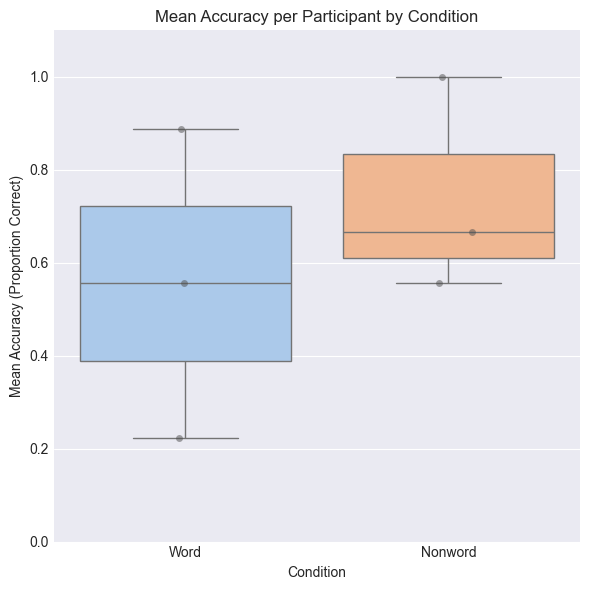

Saved RT boxplot as 'rt_boxplot.png'


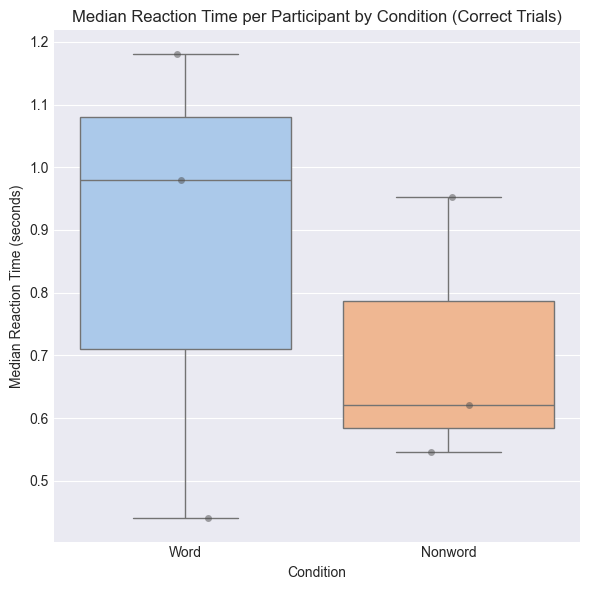


--- Overall Summary Statistics (Across Participants) ---

Accuracy:
  Mean Word Accuracy:   0.556 (SD=0.333)
  Mean Nonword Accuracy:0.741 (SD=0.231)
  Wilcoxon Test (n=3): p = 1.0000

Median Reaction Time (Correct Trials):
  Mean of Median Word RTs:   0.867s (SD=0.383)
  Mean of Median Nonword RTs:0.706s (SD=0.216)
  Wilcoxon Test (n=3): p = 0.7500

--- Script Finished ---


In [4]:
# --- Main Execution ---
if __name__ == "__main__":
    # Basic check if the path was modified
    if "REPLACE_WITH_PATH_TO_YOUR_DATA_DIRECTORY" in data_directory:
        print("Error: Please update the 'data_directory' variable with the actual path to your data files.")
    else:
        # Suppress specific warnings from libraries if they become noisy (optional)
        warnings.simplefilter(action='ignore', category=FutureWarning) # Ignore common Pandas FutureWarnings

        # 1. Load and Combine Data
        combined_data = load_and_combine_data(data_directory, columns_to_keep, essential_analysis_columns)

        if combined_data is not None:
            # 2. Clean Data
            cleaned_data = clean_data(combined_data, essential_analysis_columns)

            if cleaned_data is not None:
                # 3. Calculate Summary Statistics
                # Using _, summary_data because calculate_summary_stats returns two identical dfs in this refactor
                _, summary_data = calculate_summary_stats(cleaned_data)

                if summary_data is not None:
                     # Save combined raw data and summary data (optional)
                     try:
                         cleaned_data.to_csv("combined_cleaned_data.csv", index=False)
                         summary_data.to_csv("participant_summary_data.csv", index=False)
                         print("\nSaved combined cleaned data to 'combined_cleaned_data.csv'")
                         print("Saved participant summary data to 'participant_summary_data.csv'")
                     except Exception as e:
                         print(f"\nWarning: Could not save output CSV files: {e}")

                     # 4. Perform Analysis
                     acc_results, rt_results = perform_analysis(summary_data)

                     # 5. Create Visualizations
                     create_visualizations(summary_data)

                     # 6. Display Summary Output
                     display_summary_output(summary_data, acc_results, rt_results)

                else:
                    print("\nAnalysis halted: Could not calculate summary statistics.")
            else:
                 print("\nAnalysis halted: Data cleaning failed.")
        else:
            print("\nAnalysis halted: Data loading failed.")

    print("\n--- Script Finished ---")